# 4x3 Grid World: Monte Carlo Methods

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../Intro/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [378]:
import numpy as np
np.set_printoptions(precision=2)

In [357]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

from gym_classics.utils import print_gridworld
from gym_classics.animation import gridworld_animate
                                    
from gym_classics.algorithms import random_policy

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:75: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define the $4 \times 3$ Grid World

The used example is the simple $4 \times 3$ grid world described in AIMA Chapter 17.

![4x3 grid world description](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/AIMA_Figure_17_1.png)

AIMA Figure 17.1: (a) A simple, stochastic 
 environment that presents the agent with a sequential decision problem. (b) Illustration of the transition model of the environment: the “intended” outcome occurs with probability 0.8, but with probability 0.2 the agent moves at right angles to the intended direction. A collision with a wall results in no movement. Transitions into the two terminal states have reward +1 and -1, respectively, and all other transitions have a reward of -0.04.


`gym_classic` defines an abstract gridworld class. Here we extend the `NoisyGridWorld` which implements the non-determnistic 80/10/10 navigation actions for 
the example.

In [358]:
from gym_classics.envs.abstract.noisy_gridworld import NoisyGridworld

class OriginalClassicGridworld(NoisyGridworld):
    layout = """
|   G|
| X G|
|S   |
"""

    def __init__(self):
        super().__init__(OriginalClassicGridworld.layout)

    def _reward(self, state, action, next_state):
        return {(3, 1): -1.0, (3, 2): 1.0}.get(state, -0.04)

    def _done(self, state, action, next_state):
        return state in self._goals  

gym.register('OriginalClassicGridworld-v0', entry_point=OriginalClassicGridworld)

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment OriginalClassicGridworld-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


We can use `make()` to create registered environments. Gymnasium uses wrappers, so we have unwrap the environment first to get the extended model API.

In [359]:
gym_env = gym.make('OriginalClassicGridworld-v0')
env = gym_env.unwrapped

## Monte Carlo Prediction

Estimate the value function for a policy using sample trajectories. This is also called policy evaluation. 

We already know that we can use sampling
many trajectories from a state to estimate the state value using the average return. The idea here is that the estimate for each state in the episode can be updated with the
return over the rest of the episode.  

![Monte Carlo Prediciton](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_MC_Prediction.png)

In [360]:
manual_pol = [env.encode_action("up")] * len(env.states())
manual_pol[2] = env.encode_action("right")
manual_pol[4] = env.encode_action("right")
manual_pol[7] = env.encode_action("right")

manual_pol

[0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0]

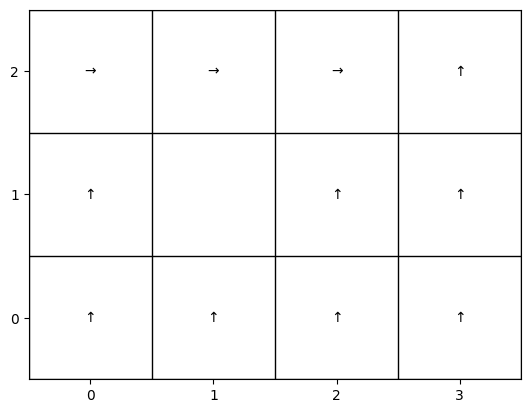

In [361]:
env.image(policy = manual_pol)

In [362]:
# Sample complete episodes. The starting (s,a) can be specified.
def sample_episode(env, policy, start_state = None, start_action = None, max_len = 1000):
 
    episode = []
    
    s, r = env.reset()
    
    if not start_state is None:
        s = start_state
        env.state = env.decode(s)
    
    step = 0
    done = False
    while not done and step < max_len:
        a = policy[s]
        
        if step == 0 and not start_action is None:
            a = start_action
        
        sp, reward, done, _, _ = env.step(a)
        episode.append((s,a,reward,sp))
        
        s = sp
        step += 1
        
    return(episode)
    
sample_episode(env, manual_pol)


[(0, 0, -0.04, 1),
 (1, 0, -0.04, 2),
 (2, 1, -0.04, 4),
 (4, 1, -0.04, 7),
 (7, 1, -0.04, 10),
 (10, 0, 1.0, 10)]

In [402]:
def MC_prediction(env, policy, discount, n = 100):
    #V = np.zeros(len(env.states()))
    Returns = [[] for _ in env.states()]
    
    for i in range(n):
        episode = sample_episode(env, policy)
        G = 0
        
        # process episode in reverse order
        for t in range(len(episode)-1, -1, -1):
            s,a,r,sp = episode[t]
            G = discount * G + r

            # use first visit only
            if not s in [step[0] for step in episode][0:t]:
                Returns[s].append(G)
                  
    # calculate all state value (np.mean unnecessarily throws a warning for empty lists)
    V = np.array([np.mean(G) if len(G) else np.nan for G in Returns])
    return V  

In [403]:
V_MC = MC_prediction(env, manual_pol, 1)
V_MC

array([ 0.64,  0.71,  0.76,  0.6 ,  0.81,  0.81,  0.39,  0.87,   nan,
       -1.  ,  1.  ])

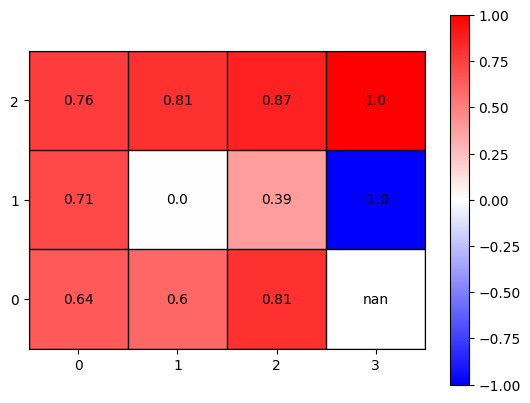

In [404]:
env.image(V_MC, labels = True)

## Monte Carlo Control

Find the optimal policy using MC.

Many $(s,a)$-pairs will never be visited when following $\pi$. We need to keep exploring! 

Options:
* Exploring starts: choose the starting $(s,a)$ for each episode randomly.
* Only consider soft policies like $\epsilon$-greedy. Soft policies have non-zero probabilities for all actions.


### On-policy MC Control with Exploring Starts

Start episodes randomly from all possible $(a,s)$ pairs.

![MC Control with ES](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_MC_Control_ES.png)

In [405]:
from collections import defaultdict

# np.argmax does not break ties randomly
def random_argmax(x):
    return np.random.choice(np.where(x == np.max(x))[0])

def MC_control_ES(env, discount, n = 100, max_episode_len = 100):
    policy = random_policy(env)
    Q = np.zeros((len(env.states()), len(env.actions())))
    Returns = defaultdict(list) # a list for each (s,a)
    
    for i in range(n):
        # Sample starting (s,a)
        s = np.random.choice(env.states())
        a = np.random.choice(env.actions())
        
        episode = sample_episode(env, policy, start_state = s, start_action = a, max_len=max_episode_len)
        G = 0
        
        # for first visit check for (s,a)
        visited = [(s,a) for s,a,r,sp in episode]
        
        # process episode in reverse order
        for t in range(len(episode)-1, -1, -1):
            s,a,r,sp = episode[t]
            G = discount * G + r

            # use first visit of (s,a) only
            if not (s,a) in visited[0:t]:
                Returns[(s,a)].append(G)
            
                # update policy
                Q[s,a] = np.mean(Returns[(s,a)])
                policy[s] = random_argmax(Q[s,:])
          
    return policy, Q

In [408]:
pol, Q = MC_control_ES(env, discount=1, n = 10000)
pol


array([0, 0, 1, 3, 1, 3, 0, 1, 3, 1, 3])

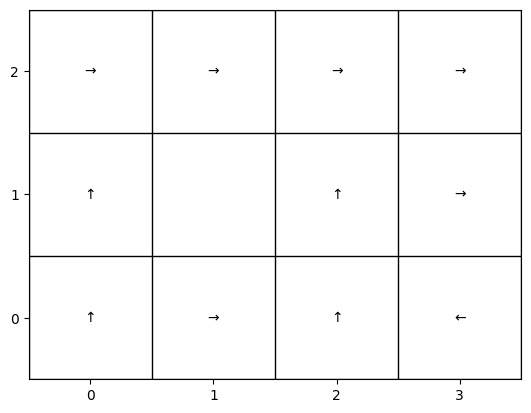

In [407]:

env.image(policy = pol)


The algorithm also estimates a Q-function with the action values for each state.

In [369]:
Q

array([[ 0.69,  0.48,  0.59,  0.62],
       [ 0.75,  0.6 ,  0.54,  0.58],
       [ 0.71,  0.8 ,  0.68,  0.72],
       [ 0.57,  0.53,  0.55,  0.63],
       [ 0.72,  0.87,  0.8 ,  0.67],
       [ 0.57,  0.45,  0.37,  0.55],
       [ 0.65, -0.61,  0.44,  0.63],
       [ 0.87,  0.92,  0.69,  0.78],
       [-0.75,  0.19,  0.25,  0.34],
       [-1.  , -1.  , -1.  , -1.  ],
       [ 1.  ,  1.  ,  1.  ,  1.  ]])

### More Algorithms

* On-policy MC control with $\epsilon$-soft policy
* Off-policy MC prediction and control using importance sampling.


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)